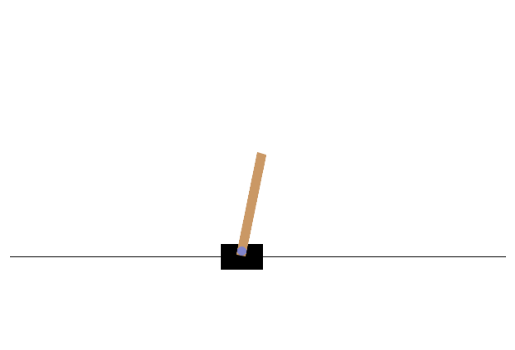

In [1]:
# Test the renderer
import gymnasium
from headless_renderer import headless_renderer

# Make gym env
env = gymnasium.make('CartPole-v1', render_mode = "rgb_array")
observation = env.reset()

# Create renderer
renderer = headless_renderer(env, True)

# Run the env
for t in range(1000):
    #Render to frames buffer
    renderer.update_display()
    action = env.action_space.sample()
    _, _, terminated, truncated, _ = env.step(action)
    done = terminated | truncated
    if done:
        break

renderer.save_video('sim.mp4')

env.close()

In [1]:
# Test the logger
from logger import logger

print("This should output if constants.logger is true:")
log = logger()
log.log("Hello World!")
log.output()

This should output if constants.logger is true:
Hello World!


Accident
[[16.0, 94.07212829589844, 2.205098326157895e-10, 0, 0], [16.0, 50.0, 0, 0, 0]]
-29.454666666666313


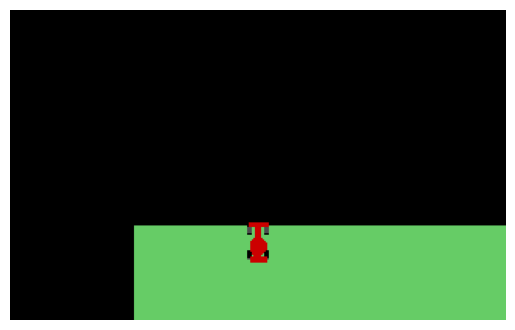

In [1]:
# Test rendering truck with given action, not an exhaustive test though, 
# might still have bugs, I suggest recover and run interactive tests.
# Known bugs: time calculation is not synchronized with real world, not sure how to fix yet
import gymnasium
import numpy as np
from headless_renderer import headless_renderer
from cargo_moving_truck_env import cargo_moving_truck_env
from constants import constants
from logger import logger

# Register environment
gymnasium.register(id = "CargoMovingTruck-v0", entry_point = cargo_moving_truck_env)

# Make gym env
env = gymnasium.make('CargoMovingTruck-v0', render_mode = "rgb_array")

# Change/Delete random seed for fixed/random generations
#observation = env.reset(seed = constants.RANDOM_SEED)
# Does negative seeds work? Yes!
# But rarely negative seeds are used, so let's make them easy and deterministic cases for debugging.
observation = env.reset(seed = -1)

# Create renderer
renderer = headless_renderer(env, True)
logger = None

# Run the env
for t in range(10000):

    #Render to frames buffer
    renderer.update_display(logger)
    
    action = np.array([0, 0.01, 0.01])
    obs, reward, terminated, truncated, info = env.step(action)
    if "logger" in info:
        logger = info["logger"]
    
    done = terminated | truncated
    if done:
        break

renderer.save_video('sim.mp4')

logger.output()

env.close()

In [1]:
import torch
# Get machine learning processing unit.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0
